# Titanic Survival Prediction

In [1]:
# Requirements:

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation

In [5]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Load Dataset

In [6]:
df = pd.read_csv("/Users/admin/Desktop/DBDA/Machine_Learning/dataset/Titanic-Dataset.csv")

In [7]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


# Basic Dataset Understanding

In [8]:
df.shape

(891, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
for column in df.columns:
    print(column,end=",")

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,

# Select Required Columns

In [12]:
df = df[["Pclass", "Sex", "Age", "Fare", "Embarked", "Survived"]]

df.head(3)

,Pclass,Sex,Age,Fare,Embarked,Survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1


# EDA: Missing Values

In [13]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
Survived      0
dtype: int64

In [14]:
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage

Pclass       0.000000
Sex          0.000000
Age         19.865320
Fare         0.000000
Embarked     0.224467
Survived     0.000000
dtype: float64

# EDA: Survival Rate

In [15]:
df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [16]:
df["Survived"].value_counts(normalize=True) * 100

0    61.616162
1    38.383838
Name: Survived, dtype: float64

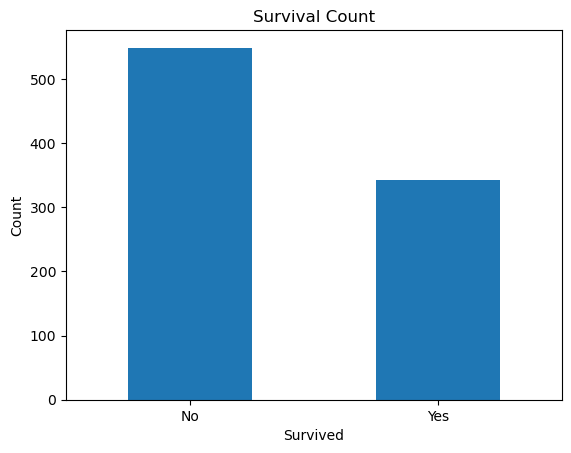

In [17]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0,1],["No","Yes"], rotation=0)
plt.show()

# EDA: Male vs Female Survival

In [18]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [19]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

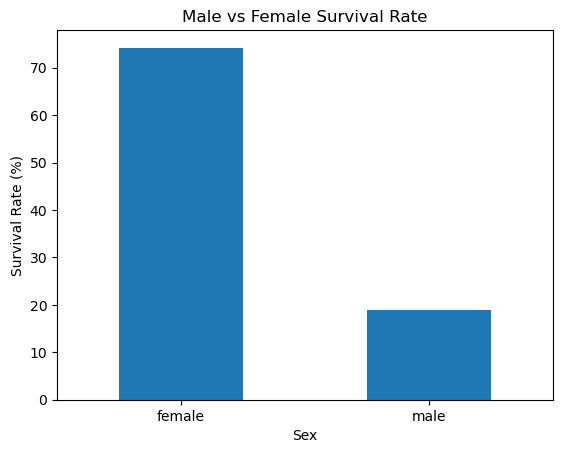

In [20]:
gender_survival.plot(kind="bar")

plt.title("Male vs Female Survival Rate")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

# EDA: Class-wise Survival

In [21]:
pd.crosstab(df["Pclass"],df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [22]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

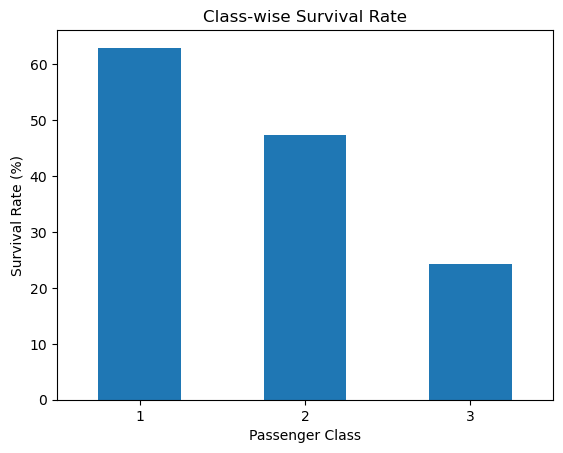

In [23]:
class_survival.plot(kind="bar")

plt.title("Class-wise Survival Rate")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

# EDA: Age Distribution

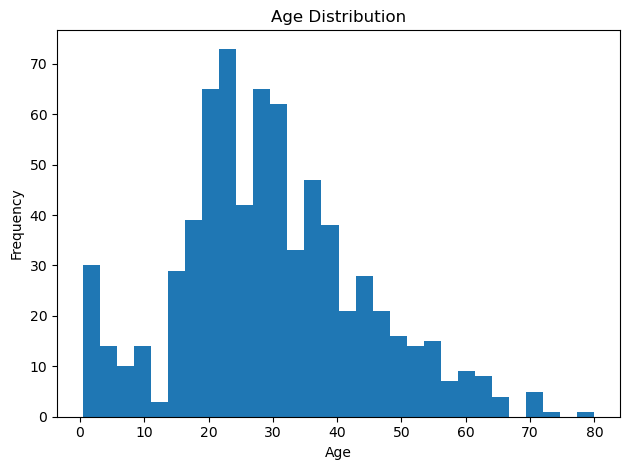

In [24]:
df["Age"].plot(kind="hist", bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [25]:
# Age distribution by survival

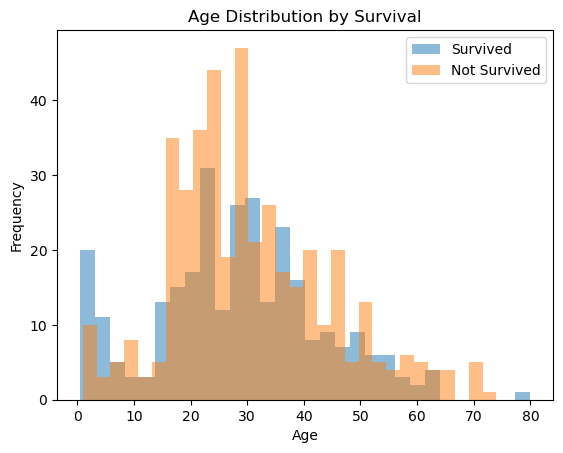

In [26]:
df[df["Survived"] == 1]["Age"].plot(kind="hist", bins=30, alpha=0.5, label="Survived")
df[df["Survived"] == 0]["Age"].plot(kind="hist", bins=30, alpha=0.5, label="Not Survived")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Handle Missing Values

In [27]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
Survived      0
dtype: int64

In [28]:
# Fill missing Age with median:

df["Age"] = df["Age"].fillna(df["Age"].median())

In [29]:
# Fill missing Embarked with mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [30]:
df.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
Survived    0
dtype: int64

# Encoding

In [31]:
df["Sex"] = df["Sex"].map({
    "male":1,
    "female":0
})

In [32]:
df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [33]:
df.head(2)

,Pclass,Sex,Age,Fare,Embarked,Survived
0,3,1,22.0,7.2500,0,0
1,1,0,38.0,71.2833,1,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   Fare      891 non-null    float64
 4   Embarked  891 non-null    int64  
 5   Survived  891 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


# Feature and Target Selection

In [35]:
x = df[["Pclass","Sex","Age","Fare","Embarked"]]
y = df["Survived"]

In [36]:
x.head()

,Pclass,Sex,Age,Fare,Embarked
0,3,1,22.0,7.2500,0
1,1,0,38.0,71.2833,1
2,3,0,26.0,7.9250,0
3,1,0,35.0,53.1000,0
4,3,1,35.0,8.0500,0


In [37]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Train-Test Split

In [38]:
x_train,x_test,y_train,y_test = train_test_split(
            x,y,test_size=0.2,random_state=42
)

In [39]:
# Check Shapes:

print("x_train shape:", x_train.shape)
print("x_test shape:", x_train.shape)
print("x_train shape:", x_train.shape)
print("y_test shape:", x_train.shape)

x_train shape: (712, 5)
x_test shape: (712, 5)
x_train shape: (712, 5)
y_test shape: (712, 5)


# Build Multiple Models

In [40]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(random_state=42),
    "SVM" : SVC(kernel="linear")
}

# Train and Evaluate All Models

In [41]:
for name,model in models.items():
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipeline.fit(x_train,y_train)
    
    y_pred = pipeline.predict(x_test)
    
    print("=" * 50)
    print("Model:", name)
    print("Accuracy:", accuracy_score(y_test,y_pred))
    print()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test,y_pred))
    print()
    print("Classification Report:")
    print(classification_report(y_test,y_pred))

Model: Logistic Regression
Accuracy: 0.7932960893854749

Confusion Matrix:
[[88 17]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179

Model: Decision Tree
Accuracy: 0.770949720670391

Confusion Matrix:
[[82 23]
 [18 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       105
           1       0.71      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179

Model: Random Forest
Accuracy: 0.8100558659217877

Confusion Matrix:
[[89 16]
 [18 56]]

Classification Report:
     

# Store Model Accuracies

In [42]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipeline.fit(x_train,y_train)
    
    y_pred = pipeline.predict(x_test)
    
    accuracy = accuracy_score(y_test,y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })
    
    results_df = pd.DataFrame(results)
    results_df

In [43]:
results_df

,Model,Accuracy
0,Logistic Regression,0.793296
1,Decision Tree,0.770950
2,Random Forest,0.810056
3,SVM,0.782123


In [44]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.810056
0,Logistic Regression,0.793296
3,SVM,0.782123
1,Decision Tree,0.770950


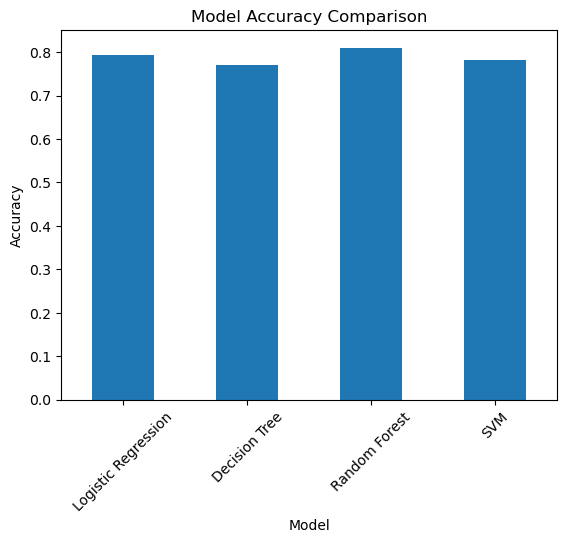

In [45]:
results_df.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Train Best Model Seperately

In [46]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

best_model.fit(x_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [47]:
y_pred = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8100558659217877
[[89 16]
 [18 56]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Predict Survival for New Passenger

In [48]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],
    "Age": [22],
    "Fare": [7.25],
    "Embarked": [0]
})

prediction = best_model.predict(new_passenger)

print(prediction)

[0]


In [49]:
if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survived")

Passenger Did Not Survived


In [50]:
# Another Example: Female Passenger in 1st Class

In [51]:
new_passenger = pd.DataFrame({
    "Pclass":[1],
    "Sex":[0],
    "Age":[28],
    "Fare":[80],
    "Embarked":[1]
})

prediction = best_model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survived")

Passenger Survived
